
# Loan Prediction - Exploratory Data Analysis (EDA)

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [43]:
# Load Data
df_loan = pd.read_csv('./datasets/train_ctrUa4K.csv')

print(f'Shape: {df_loan.shape}')
display(df_loan.head())

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Dataset Overview

In [46]:
# Basic statistics of numerical columns
df_loan.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


## 2. Missing Value Analysis

,Missing Count,Missing %
Credit_History,50,8.140000
Self_Employed,32,5.210000
LoanAmount,22,3.580000
Dependents,15,2.440000
Loan_Amount_Term,14,2.280000
Gender,13,2.120000
Married,3,0.490000


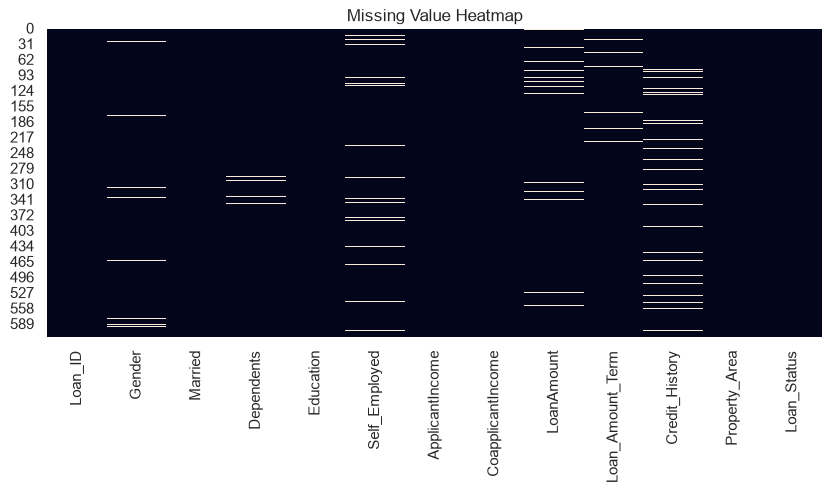

In [48]:
missing = pd.DataFrame({
    'Missing Count': df_loan.isnull().sum(),
    'Missing %': round(df_loan.isnull().mean()*100,2)
})

missing = missing[missing['Missing Count']>0].sort_values('Missing Count',ascending=False)

display(
    missing.style.background_gradient(cmap='Reds')
)

plt.figure(figsize=(10,4))
sns.heatmap(df_loan.isnull(), cbar=False)
plt.title('Missing Value Heatmap')
plt.show()

In [49]:
# df_loan['Loan_Status'].value_counts(dropna=False).reset_index()
df_temp = df_loan.groupby(by='Loan_Status', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Loan_Status,count,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,N,192,5446.078125,1877.807292,151.220994,344.064516,0.541899
1,Y,422,5384.068720,1504.516398,144.294404,341.072464,0.981818


In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_loan['Loan_Status'] = le.fit_transform(df_loan['Loan_Status'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'N': np.int64(0), 'Y': np.int64(1)}


In [51]:
df_temp = df_loan.groupby(by='Gender', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Gender,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Female,112,0.669643,4643.473214,1108.008929,126.697248,352.293578,0.831683
1,Male,489,0.693252,5446.460123,1742.932352,149.265957,339.665272,0.847007
2,NaN,13,0.615385,10333.538462,1465.692308,208.538462,341.538462,0.750000


In [52]:
df_loan['Gender'] = np.where(
    df_loan['Gender'].isna(), np.where(df_loan['ApplicantIncome'] < 5000, 'Female', 'Male'), df_loan['Gender']
)
le = LabelEncoder()
df_loan['Gender'] = le.fit_transform(df_loan['Gender'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'Female': np.int64(0), 'Male': np.int64(1)}


In [53]:
# df_loan['Education'].value_counts(dropna=False).reset_index()
df_temp = df_loan.groupby(by='Education', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Education,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,Graduate,480,0.708333,5857.433333,1717.474833,154.060215,344.669492,0.857788
1,Not Graduate,134,0.611940,3777.283582,1276.544776,118.409449,332.156250,0.785124


In [54]:
le = LabelEncoder()
df_loan['Education'] = le.fit_transform(df_loan['Education'])
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}


In [55]:
# df_loan['Married'].value_counts(dropna=False).reset_index()
df_temp = df_loan.groupby(by='Married', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Married,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,No,213,0.629108,4970.384977,1316.558685,128.883495,351.115385,0.839196
1,Yes,398,0.716080,5629.173367,1794.632965,155.750000,336.987147,0.842541
2,NaN,3,1.000000,6207.000000,251.333333,159.000000,360.000000,1.000000


In [56]:
df_loan['Married'] = df_loan['Married'].fillna("Yes")
le = LabelEncoder()
df_loan['Married'] = le.fit_transform(df_loan['Married'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 
df_loan['Married'].value_counts(dropna=False).reset_index()

{'No': np.int64(0), 'Yes': np.int64(1)}


,Married,count
0,1,401
1,0,213


In [57]:
# df_loan['Self_Employed'].value_counts(dropna=False).reset_index()
df_temp = df_loan.groupby(by='Self_Employed', as_index=False, dropna=False).agg({
    'Loan_ID': 'count', 'Loan_Status': 'mean', 'ApplicantIncome': 'mean', 'CoapplicantIncome': 'mean', 
    'LoanAmount': 'mean', 'Loan_Amount_Term': 'mean', 'Credit_History': 'mean'
}).rename(columns={'Loan_ID': 'count'})
df_temp.head()

,Self_Employed,count,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,No,500,0.686000,5049.748000,1580.989840,141.748963,343.263804,0.835853
1,Yes,82,0.682927,7380.817073,1501.341463,172.000000,336.300000,0.840000
2,NaN,32,0.718750,5863.218750,2557.500000,153.709677,336.774194,0.961538


In [58]:
df_loan['Self_Employed'] = df_loan['Self_Employed'].fillna("No")
le = LabelEncoder()
df_loan['Self_Employed'] = le.fit_transform(df_loan['Self_Employed'])
print(dict(zip(le.classes_, le.transform(le.classes_)))) 

{'No': np.int64(0), 'Yes': np.int64(1)}


In [39]:
df_loan['Property_Area'].value_counts(dropna=False).reset_index()

,Property_Area,count
0,Semiurban,233
1,Urban,202
2,Rural,179


In [40]:
df_area = pd.get_dummies(df_loan['Property_Area'],drop_first=True, dtype=int )
df_loan = pd.concat([df_loan, df_area], axis=1)
df_loan.head() 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Semiurban,Urban
0,LP001002,1,0,0,0,0,5849,0.0,NaN,360.0,1.0,Urban,1,0,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,Rural,0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,Urban,1,0,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,Urban,1,0,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,Urban,1,0,1


In [41]:
df_loan.describe()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Semiurban,Urban
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000,614.000000,614.000000
mean,0.804560,0.653094,0.218241,0.133550,5403.459283,1621.245798,146.412162,342.00000,0.842199,0.687296,0.379479,0.328990
std,0.396862,0.476373,0.413389,0.340446,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.463973,0.485653,0.470229
min,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.00000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.000000,360.00000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.00000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,168.000000,360.00000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000,1.000000,1.000000
